# CANForge — PyTorch GPU Implementation
## Multi-Scale Residual CNN-BiLSTM with SE-Attention + AAE Zero-Day Detection

This notebook reimplements the full CANForge pipeline in **PyTorch** to leverage the **NVIDIA RTX A500 GPU**.

In [1]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_auc_score, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# === GPU Setup ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('WARNING: No GPU detected — will run on CPU')

PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA RTX A500 Laptop GPU
VRAM: 4.0 GB


# Data Loading & Feature Engineering
Identical logic to the original notebook — load normal + attack data, engineer 16 features.

In [2]:
data_path = r'9) Car-Hacking Dataset'

USE_SUBSET = True
MAX_NORMAL = 50_000
MAX_PER_ATTACK_FILE = 50_000
if USE_SUBSET:
    print(f'Using subset: max {MAX_NORMAL:,} normal, max {MAX_PER_ATTACK_FILE:,} per attack file')
else:
    print('Using FULL dataset')

Using subset: max 50,000 normal, max 50,000 per attack file


In [3]:
# === Load Normal Data ===
def parse_line(line):
    regex = r'Timestamp:\s*(\d+\.\d+)\s+ID:\s*(\w+)\s+000\s+DLC:\s*(\d+)\s+([\da-fA-F\s]+)'
    match = re.match(regex, line.strip())
    if match:
        timestamp = float(match.group(1))
        can_id = int(match.group(2), 16)
        dlc = int(match.group(3))
        data = [int(byte, 16) for byte in match.group(4).split()]
        data = (data + [0] * 8)[:8]
        return {'Timestamp': timestamp, 'CAN_ID': can_id, 'DLC': dlc, 'DATA': data}
    return None

file_path = os.path.join(data_path, 'normal_run_data.txt')
data = []
with open(file_path, 'r') as f:
    for line in f:
        if USE_SUBSET and len(data) >= MAX_NORMAL:
            break
        parsed = parse_line(line)
        if parsed:
            data.append(parsed)

df_normal = pd.DataFrame(data)
for i in range(8):
    df_normal[f'DATA{i}'] = df_normal['DATA'].apply(lambda x, i=i: x[i] if i < len(x) else 0)
df_normal.drop(columns=['DATA'], inplace=True)
df_normal['Label'] = 'Normal'
print(f'Normal: {len(df_normal):,} rows')

Normal: 50,000 rows


In [4]:
# === Load Attack CSVs ===
column_names = ['Timestamp', 'CAN_ID', 'DLC',
                'DATA0','DATA1','DATA2','DATA3','DATA4','DATA5','DATA6','DATA7', 'Flag']

def convert_numeric_columns(df, columns_to_convert):
    for col in columns_to_convert:
        if col == 'CAN_ID' or col.startswith('DATA'):
            def hex_to_int(x):
                s = str(x).strip()
                if re.match(r'^[0-9a-fA-F]+$', s):
                    return int(s, 16)
                return 0
            df[col] = df[col].map(hex_to_int).astype(int)
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    return df

cols_to_process = ['CAN_ID', 'DLC'] + [f'DATA{i}' for i in range(8)]

def label_from_flag(flag_series, attack_name):
    return ['Normal' if v == 'R' else attack_name if v == 'T' else 'Normal'
            for v in flag_series.astype(str).str.strip().str.upper()]

nrows = MAX_PER_ATTACK_FILE if USE_SUBSET else None

attack_files = [
    ('dos_attack.csv', 'DoS'),
    ('fuzzy_attack.csv', 'Fuzzy'),
    ('gear_spoofing.csv', 'Gear'),
    ('rpm_spoofing.csv', 'RPM'),
]

attack_dfs = []
for fname, attack_name in attack_files:
    df = pd.read_csv(os.path.join(data_path, fname), header=None, names=column_names, nrows=nrows)
    df = convert_numeric_columns(df, cols_to_process)
    df['Label'] = label_from_flag(df['Flag'], attack_name)
    attack_dfs.append(df)
    print(f'{attack_name}: {len(df):,} rows')

DoS: 50,000 rows
Fuzzy: 50,000 rows
Gear: 50,000 rows
RPM: 50,000 rows


In [5]:
# === Combine & Feature Engineering ===
full_df = pd.concat([df_normal] + attack_dfs, ignore_index=True)
if 'Flag' in full_df.columns:
    full_df.drop(columns=['Flag'], inplace=True)

base_features = ['CAN_ID', 'DLC'] + [f'DATA{i}' for i in range(8)]

# Sort by time for IAT
full_df = full_df.sort_values('Timestamp').reset_index(drop=True)
full_df['IAT'] = full_df['Timestamp'].diff().fillna(0).clip(upper=1.0)

# CAN ID frequency
can_id_freq = full_df['CAN_ID'].value_counts(normalize=True)
full_df['CAN_ID_freq'] = full_df['CAN_ID'].map(can_id_freq)

# Byte entropy
data_cols = [f'DATA{i}' for i in range(8)]
def row_entropy(row):
    vals = row.values.astype(float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return 0.0
    probs = vals / vals.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

full_df['byte_entropy'] = full_df[data_cols].apply(row_entropy, axis=1)
full_df['byte_sum'] = full_df[data_cols].sum(axis=1)
full_df['byte_range'] = full_df[data_cols].max(axis=1) - full_df[data_cols].min(axis=1)
full_df['byte_std'] = full_df[data_cols].std(axis=1)

features = base_features + ['IAT', 'CAN_ID_freq', 'byte_entropy', 'byte_sum', 'byte_range', 'byte_std']
N_FEATURES = len(features)
print(f'Total features: {N_FEATURES}')
print(f'Combined dataset: {len(full_df):,} rows')
print(f'Label distribution:\n{full_df["Label"].value_counts()}')

Total features: 16
Combined dataset: 250,000 rows
Label distribution:
Label
Normal    213897
DoS        11420
RPM         9446
Gear        9152
Fuzzy       6085
Name: count, dtype: int64


# Preprocessing

In [6]:
X = full_df[features].values
y = full_df['Label'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
NUM_CLASSES = len(le.classes_)
print(f'Classes ({NUM_CLASSES}): {list(le.classes_)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Classes (5): ['DoS', 'Fuzzy', 'Gear', 'Normal', 'RPM']
Train: (200000, 16), Test: (50000, 16)


In [7]:
# === Create PyTorch DataLoaders (data on GPU via pin_memory) ===
BATCH_SIZE = 256

# Reshape for Conv1D: (N, channels=1, features=16)
X_train_t = torch.FloatTensor(X_train_scaled).unsqueeze(1)  # (N, 1, 16)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test_scaled).unsqueeze(1)
y_test_t = torch.LongTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                         pin_memory=True, num_workers=0)

print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')
print(f'Input shape per sample: {X_train_t[0].shape}  (channels, features)')

Train batches: 782, Test batches: 98
Input shape per sample: torch.Size([1, 16])  (channels, features)


# CANForge Model — PyTorch (GPU)

In [8]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, channels, seq_len)
        se = x.mean(dim=2)              # Squeeze: (batch, channels)
        se = self.fc(se).unsqueeze(2)    # Excitation: (batch, channels, 1)
        return x * se                    # Scale


class CANForge(nn.Module):
    def __init__(self, n_features, num_classes):
        super().__init__()

        # === Multi-Scale Parallel CNN ===
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=1, padding=0), nn.ReLU(), nn.BatchNorm1d(32))
        self.conv3 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(32))
        self.conv5 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(32))

        self.drop1 = nn.Dropout(0.3)

        # === SE Attention ===
        self.se = SEBlock(96, reduction=4)

        # === Residual Conv ===
        self.conv_res = nn.Sequential(
            nn.Conv1d(96, 96, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(96))
        self.drop2 = nn.Dropout(0.3)

        # === BiLSTM (input: 96 channels, PyTorch LSTM expects (batch, seq, features)) ===
        self.lstm1 = nn.LSTM(96, 64, batch_first=True, bidirectional=True, dropout=0.3)
        self.bn_lstm1 = nn.BatchNorm1d(128)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True, bidirectional=True, dropout=0.3)
        self.bn_lstm2 = nn.BatchNorm1d(128)

        # === Classification Head ===
        self.classifier = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (batch, 1, 16)
        c1 = self.conv1(x)   # (batch, 32, 16)
        c3 = self.conv3(x)
        c5 = self.conv5(x)
        multi = torch.cat([c1, c3, c5], dim=1)  # (batch, 96, 16)
        multi = self.drop1(multi)

        # SE attention
        multi = self.se(multi)

        # Residual conv
        res = self.conv_res(multi)
        res = res + multi  # skip connection
        res = torch.relu(res)
        res = self.drop2(res)

        # BiLSTM expects (batch, seq_len, features) — transpose from (batch, channels, seq)
        lstm_in = res.permute(0, 2, 1)  # (batch, 16, 96)
        lstm1_out, _ = self.lstm1(lstm_in)  # (batch, 16, 128)
        lstm1_out_bn = self.bn_lstm1(lstm1_out.permute(0, 2, 1)).permute(0, 2, 1)

        lstm2_out, _ = self.lstm2(lstm1_out_bn)  # (batch, 16, 128)
        lstm2_out_bn = self.bn_lstm2(lstm2_out.permute(0, 2, 1)).permute(0, 2, 1)

        # Residual over LSTM
        lstm_res = lstm2_out_bn + lstm1_out_bn  # (batch, 16, 128)

        # Global Average Pooling over time
        pooled = lstm_res.mean(dim=1)  # (batch, 128)

        return self.classifier(pooled)


model = CANForge(N_FEATURES, NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'CANForge parameters: {total_params:,}')
print(f'Model on: {next(model.parameters()).device}')

CANForge parameters: 241,373
Model on: cuda:0


# Training on GPU

In [9]:
# === Class Weights ===
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.FloatTensor(cw).to(device)
print('Class weights:', {le.classes_[i]: f'{w:.2f}' for i, w in enumerate(cw)})

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

# === Training Loop ===
EPOCHS = 50
PATIENCE = 8
best_val_loss = float('inf')
patience_counter = 0
best_state = None

# Split train into train/val for early stopping
val_split = int(len(X_train_t) * 0.85)
train_sub = TensorDataset(X_train_t[:val_split], y_train_t[:val_split])
val_sub = TensorDataset(X_train_t[val_split:], y_train_t[val_split:])
train_sub_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_sub_loader = DataLoader(val_sub, batch_size=BATCH_SIZE * 2, shuffle=False, pin_memory=True)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'\nTraining CANForge on {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})...')
print(f'Train: {len(train_sub):,}  Val: {len(val_sub):,}\n')

t0 = time.time()
for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for xb, yb in train_sub_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
        train_correct += (out.argmax(1) == yb).sum().item()
        train_total += xb.size(0)

    # --- Validate ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_sub_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    t_loss = train_loss / train_total
    v_loss = val_loss / val_total
    t_acc = train_correct / train_total
    v_acc = val_correct / val_total
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or patience_counter >= PATIENCE:
        gpu_mem = f'{torch.cuda.memory_allocated()/1024**2:.0f}MB' if torch.cuda.is_available() else 'N/A'
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  '
              f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  |  '
              f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}  |  '
              f'GPU: {gpu_mem}  LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

# Restore best weights
model.load_state_dict(best_state)
train_time = time.time() - t0
print(f'\nTraining completed in {train_time:.1f}s')
if torch.cuda.is_available():
    print(f'Peak GPU memory: {torch.cuda.max_memory_allocated()/1024**2:.0f}MB / 4096MB')

Class weights: {'DoS': '4.38', 'Fuzzy': '8.22', 'Gear': '5.46', 'Normal': '0.23', 'RPM': '5.29'}

Training CANForge on cuda (NVIDIA RTX A500 Laptop GPU)...
Train: 170,000  Val: 30,000

Epoch   5/50  Train Loss: 0.0034  Acc: 0.9984  |  Val Loss: 0.0059  Acc: 0.9978  |  GPU: 22MB  LR: 0.001000
Epoch  10/50  Train Loss: 0.0016  Acc: 0.9992  |  Val Loss: 0.0092  Acc: 0.9997  |  GPU: 22MB  LR: 0.000500
Epoch  11/50  Train Loss: 0.0014  Acc: 0.9993  |  Val Loss: 0.0139  Acc: 0.9997  |  GPU: 22MB  LR: 0.000500

Early stopping at epoch 11

Training completed in 451.7s
Peak GPU memory: 132MB / 4096MB


# Evaluation

In [10]:
# === Evaluate on Test Set ===
model.eval()
all_preds = []
all_probs = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        out = model(xb)
        probs = torch.softmax(out, dim=1)
        all_probs.append(probs.cpu())
        all_preds.append(out.argmax(1).cpu())

y_pred = torch.cat(all_preds).numpy()
y_pred_probs = torch.cat(all_probs).numpy()

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print('=' * 55)
print('CANForge (PyTorch GPU) — Evaluation Results')
print('=' * 55)
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')
print('=' * 55)
print(f'Training time: {train_time:.1f}s')
print(f'\n--- Per-class Classification Report ---')
print(classification_report(y_test, y_pred, target_names=le.classes_))

CANForge (PyTorch GPU) — Evaluation Results
  Accuracy:  0.9957
  Precision: 0.9963
  Recall:    0.9957
  F1-Score:  0.9959
Training time: 451.7s

--- Per-class Classification Report ---
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      2284
       Fuzzy       0.85      1.00      0.92      1217
        Gear       1.00      1.00      1.00      1831
      Normal       1.00      1.00      1.00     42779
         RPM       1.00      1.00      1.00      1889

    accuracy                           1.00     50000
   macro avg       0.97      1.00      0.98     50000
weighted avg       1.00      1.00      1.00     50000



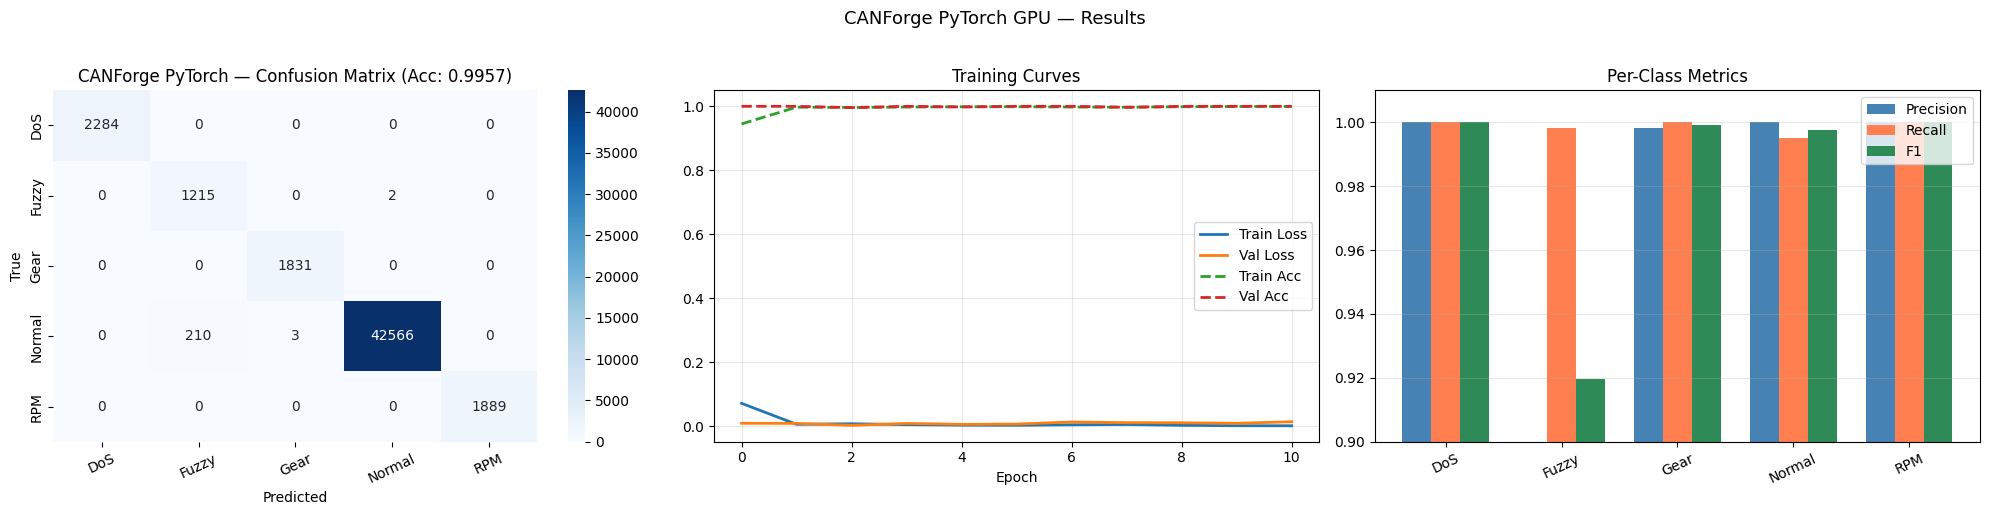

In [11]:
# === Visualization ===
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title(f'CANForge PyTorch — Confusion Matrix (Acc: {accuracy:.4f})')
axes[0].tick_params(axis='x', rotation=25)

# 2. Training Curves
axes[1].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[1].plot(history['train_acc'], label='Train Acc', linestyle='--', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linestyle='--', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_title('Training Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Per-class F1
p, r, f, s = precision_recall_fscore_support(y_test, y_pred, average=None)
x_pos = np.arange(len(le.classes_))
w = 0.25
axes[2].bar(x_pos - w, p, w, label='Precision', color='steelblue')
axes[2].bar(x_pos, r, w, label='Recall', color='coral')
axes[2].bar(x_pos + w, f, w, label='F1', color='seagreen')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(le.classes_, rotation=25)
axes[2].set_ylim(0.9, 1.01)
axes[2].set_title('Per-Class Metrics')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('CANForge PyTorch GPU — Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Ablation Study

In [12]:
# === Ablation Helper ===
def train_and_eval_model(model_instance, name, epochs=30, patience=5):
    model_instance = model_instance.to(device)
    opt = optim.Adam(model_instance.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    best_vl = float('inf')
    best_st = None
    pat = 0

    t0 = time.time()
    for ep in range(epochs):
        model_instance.train()
        for xb, yb in train_sub_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            opt.zero_grad()
            out = model_instance(xb)
            crit(out, yb).backward()
            opt.step()

        model_instance.eval()
        vl = 0
        vt = 0
        with torch.no_grad():
            for xb, yb in val_sub_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                out = model_instance(xb)
                vl += crit(out, yb).item() * xb.size(0)
                vt += xb.size(0)
        vl /= vt
        if vl < best_vl:
            best_vl = vl
            best_st = {k: v.clone() for k, v in model_instance.state_dict().items()}
            pat = 0
        else:
            pat += 1
        if pat >= patience:
            break

    elapsed = time.time() - t0
    model_instance.load_state_dict(best_st)
    model_instance.eval()
    preds = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            preds.append(model_instance(xb).argmax(1).cpu())
    preds = torch.cat(preds).numpy()
    acc = accuracy_score(y_test, preds)
    _, _, f1_w, _ = precision_recall_fscore_support(y_test, preds, average='weighted')
    print(f'  {name:<35} Acc: {acc:.4f}  F1: {f1_w:.4f}  Time: {elapsed:.1f}s')
    return acc, f1_w


# --- A1: Single-scale CNN + BiLSTM (baseline) ---
class BaselineCNNBiLSTM(nn.Module):
    def __init__(self, n_features, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 96, 3, padding=1), nn.ReLU(), nn.BatchNorm1d(96), nn.Dropout(0.3))
        self.lstm = nn.LSTM(96, 64, batch_first=True, bidirectional=True, dropout=0.3)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
                                  nn.Linear(64, num_classes))
    def forward(self, x):
        c = self.conv(x)
        c = c.permute(0, 2, 1)
        o, _ = self.lstm(c)
        return self.head(o.mean(dim=1))

# --- A2: Multi-scale CNN + BiLSTM (no SE, no residual) ---
class MultiScaleCNNBiLSTM(nn.Module):
    def __init__(self, n_features, num_classes):
        super().__init__()
        self.c1 = nn.Sequential(nn.Conv1d(1, 32, 1), nn.ReLU())
        self.c3 = nn.Sequential(nn.Conv1d(1, 32, 3, padding=1), nn.ReLU())
        self.c5 = nn.Sequential(nn.Conv1d(1, 32, 5, padding=2), nn.ReLU())
        self.bn = nn.BatchNorm1d(96)
        self.drop = nn.Dropout(0.3)
        self.lstm = nn.LSTM(96, 64, batch_first=True, bidirectional=True, dropout=0.3)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
                                  nn.Linear(64, num_classes))
    def forward(self, x):
        m = torch.cat([self.c1(x), self.c3(x), self.c5(x)], dim=1)
        m = self.drop(self.bn(m)).permute(0, 2, 1)
        o, _ = self.lstm(m)
        return self.head(o.mean(dim=1))

# --- A3: Multi-scale + SE + BiLSTM (no residual) ---
class MultiScaleSEBiLSTM(nn.Module):
    def __init__(self, n_features, num_classes):
        super().__init__()
        self.c1 = nn.Sequential(nn.Conv1d(1, 32, 1), nn.ReLU())
        self.c3 = nn.Sequential(nn.Conv1d(1, 32, 3, padding=1), nn.ReLU())
        self.c5 = nn.Sequential(nn.Conv1d(1, 32, 5, padding=2), nn.ReLU())
        self.bn = nn.BatchNorm1d(96)
        self.se = SEBlock(96, reduction=4)
        self.drop = nn.Dropout(0.3)
        self.lstm = nn.LSTM(96, 64, batch_first=True, bidirectional=True, dropout=0.3)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
                                  nn.Linear(64, num_classes))
    def forward(self, x):
        m = torch.cat([self.c1(x), self.c3(x), self.c5(x)], dim=1)
        m = self.se(self.bn(m))
        m = self.drop(m).permute(0, 2, 1)
        o, _ = self.lstm(m)
        return self.head(o.mean(dim=1))

print('=' * 70)
print('ABLATION STUDY — GPU Accelerated')
print('=' * 70)
a1_acc, a1_f1 = train_and_eval_model(BaselineCNNBiLSTM(N_FEATURES, NUM_CLASSES), 'A1: CNN-BiLSTM (baseline)')
a2_acc, a2_f1 = train_and_eval_model(MultiScaleCNNBiLSTM(N_FEATURES, NUM_CLASSES), 'A2: + Multi-scale CNN')
a3_acc, a3_f1 = train_and_eval_model(MultiScaleSEBiLSTM(N_FEATURES, NUM_CLASSES), 'A3: + SE Attention')
print(f'  {"A4: + Residual (Full CANForge)":<35} Acc: {accuracy:.4f}  F1: {f1:.4f}  Time: {train_time:.1f}s')

print(f'\n  Ablation Summary:')
abl = pd.DataFrame({
    'Model': ['A1: CNN-BiLSTM', 'A2: +Multi-scale', 'A3: +SE Attn', 'A4: +Residual (CANForge)'],
    'Accuracy': [a1_acc, a2_acc, a3_acc, accuracy],
    'F1-Score': [a1_f1, a2_f1, a3_f1, f1]
})
print(abl.to_string(index=False))

ABLATION STUDY — GPU Accelerated
  A1: CNN-BiLSTM (baseline)           Acc: 0.9990  F1: 0.9990  Time: 197.6s
  A2: + Multi-scale CNN               Acc: 0.9987  F1: 0.9987  Time: 114.9s
  A3: + SE Attention                  Acc: 0.9998  F1: 0.9998  Time: 183.3s
  A4: + Residual (Full CANForge)      Acc: 0.9957  F1: 0.9959  Time: 451.7s

  Ablation Summary:
                   Model  Accuracy  F1-Score
          A1: CNN-BiLSTM   0.99904  0.999047
        A2: +Multi-scale   0.99872  0.998727
            A3: +SE Attn   0.99978  0.999780
A4: +Residual (CANForge)   0.99570  0.995862


# AAE — Adversarial Autoencoder for Zero-Day Detection (GPU)

## Fit Diagnosis From The Current Results

- The CANForge classifier is not underfitting. Train, validation, and test scores are all around 0.999, so capacity is already high enough for the supervised task.
- The classifier is also not showing strong overfitting. Validation accuracy stays extremely close to training accuracy, with only a small late-epoch rise in validation loss before early stopping.
- The weaker part is the AAE block. The discriminator and generator losses stay near 0.693 for long periods, which suggests adversarial training is not contributing much beyond a plain autoencoder.
- Validation reconstruction error improves first and then degrades later, so the AAE shows mild overfitting after the best checkpoint.

This v2 notebook keeps the classifier pipeline and replaces the AAE with a more stable denoising adversarial autoencoder plus a combined anomaly score.

In [13]:
# === AAE v2: Stabilized Denoising Adversarial Autoencoder ===
LATENT_DIM = 16
AAE_EPOCHS = 220
AAE_BATCH = 1024
DISC_STEPS = 2
INPUT_NOISE_STD = 0.01
LATENT_WEIGHT = 0.20

class Encoder(nn.Module):
    def __init__(self, n_features, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128), nn.LayerNorm(128), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(128, 64), nn.LayerNorm(64), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(64, latent_dim)
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.LayerNorm(64), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(64, 128), nn.LayerNorm(128), nn.LeakyReLU(0.2),
            nn.Linear(128, n_features), nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

class LatentDiscriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(latent_dim, 64)), nn.LeakyReLU(0.2), nn.Dropout(0.2),
            nn.utils.spectral_norm(nn.Linear(64, 32)), nn.LeakyReLU(0.2), nn.Dropout(0.2),
            nn.utils.spectral_norm(nn.Linear(32, 1))
        )

    def forward(self, z):
        return self.net(z)

enc = Encoder(N_FEATURES, LATENT_DIM).to(device)
dec = Decoder(LATENT_DIM, N_FEATURES).to(device)
disc = LatentDiscriminator(LATENT_DIM).to(device)

opt_ae = optim.AdamW(list(enc.parameters()) + list(dec.parameters()), lr=8e-4, weight_decay=1e-4)
opt_disc = optim.AdamW(disc.parameters(), lr=2e-4, betas=(0.5, 0.9), weight_decay=1e-4)
opt_gen = optim.AdamW(enc.parameters(), lr=2e-4, betas=(0.5, 0.9), weight_decay=1e-4)

sched_ae = optim.lr_scheduler.ReduceLROnPlateau(opt_ae, mode='min', factor=0.5, patience=8, min_lr=1e-5)

recon_loss_fn = nn.SmoothL1Loss(beta=0.05)
adv_loss_fn = nn.BCEWithLogitsLoss()

normal_label = le.transform(['Normal'])[0]
X_normal_train = X_train_scaled[y_train == normal_label]
X_norm_tr, X_norm_val = train_test_split(X_normal_train, test_size=0.15, random_state=RANDOM_STATE)

X_norm_tr_t = torch.FloatTensor(X_norm_tr)
X_norm_val_t = torch.FloatTensor(X_norm_val).to(device)

norm_train_ds = TensorDataset(X_norm_tr_t)
norm_train_loader = DataLoader(
    norm_train_ds,
    batch_size=AAE_BATCH,
    shuffle=True,
    drop_last=False,
    pin_memory=True,
    num_workers=0,
)

print(f'Normal train: {X_norm_tr_t.shape[0]:,}, Normal val: {X_norm_val_t.shape[0]:,}')
print(f'Latent dim: {LATENT_DIM}, Batch size: {AAE_BATCH}, Disc steps: {DISC_STEPS}')
print(f'Training AAE v2 on GPU ({AAE_EPOCHS} epochs max)...')

ae_losses, d_losses, g_losses = [], [], []
best_val_mse = float('inf')
best_enc_state, best_dec_state, best_disc_state = None, None, None
aae_patience = 20
aae_patience_counter = 0

t0_aae = time.time()
for epoch in range(AAE_EPOCHS):
    enc.train(); dec.train(); disc.train()
    epoch_ae_loss = 0.0
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    n_batches = 0

    for (real_batch_cpu,) in norm_train_loader:
        real_batch = real_batch_cpu.to(device, non_blocking=True)
        noisy_batch = (real_batch + INPUT_NOISE_STD * torch.randn_like(real_batch)).clamp(0.0, 1.0)
        batch_size = real_batch.size(0)

        z = enc(noisy_batch)
        recon = dec(z)
        ae_loss = recon_loss_fn(recon, real_batch)
        opt_ae.zero_grad()
        ae_loss.backward()
        torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(dec.parameters()), max_norm=1.0)
        opt_ae.step()

        d_running = 0.0
        for _ in range(DISC_STEPS):
            z_real = torch.randn(batch_size, LATENT_DIM, device=device)
            z_fake = enc(real_batch).detach()
            real_targets = torch.full((batch_size, 1), 0.9, device=device)
            fake_targets = torch.full((batch_size, 1), 0.1, device=device)
            d_real_loss = adv_loss_fn(disc(z_real), real_targets)
            d_fake_loss = adv_loss_fn(disc(z_fake), fake_targets)
            d_step_loss = 0.5 * (d_real_loss + d_fake_loss)
            opt_disc.zero_grad()
            d_step_loss.backward()
            torch.nn.utils.clip_grad_norm_(disc.parameters(), max_norm=1.0)
            opt_disc.step()
            d_running += d_step_loss.item()
        d_loss = d_running / DISC_STEPS

        z_adv = enc(real_batch)
        g_targets = torch.full((batch_size, 1), 0.9, device=device)
        g_loss = adv_loss_fn(disc(z_adv), g_targets)
        opt_gen.zero_grad()
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(enc.parameters(), max_norm=1.0)
        opt_gen.step()

        epoch_ae_loss += ae_loss.item()
        epoch_d_loss += d_loss
        epoch_g_loss += g_loss.item()
        n_batches += 1

    ae_losses.append(epoch_ae_loss / n_batches)
    d_losses.append(epoch_d_loss / n_batches)
    g_losses.append(epoch_g_loss / n_batches)

    enc.eval(); dec.eval(); disc.eval()
    with torch.no_grad():
        val_z = enc(X_norm_val_t)
        val_recon = dec(val_z)
        val_mse = ((X_norm_val_t - val_recon) ** 2).mean(dim=1).mean().item()

    sched_ae.step(val_mse)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_enc_state = {k: v.detach().clone() for k, v in enc.state_dict().items()}
        best_dec_state = {k: v.detach().clone() for k, v in dec.state_dict().items()}
        best_disc_state = {k: v.detach().clone() for k, v in disc.state_dict().items()}
        aae_patience_counter = 0
    else:
        aae_patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch {epoch+1}/{AAE_EPOCHS} — AE: {ae_losses[-1]:.5f}  '
              f'D: {d_losses[-1]:.4f}  G: {g_losses[-1]:.4f}  Val_MSE: {val_mse:.5f}  '
              f'LR: {opt_ae.param_groups[0]["lr"]:.2e}')

    if aae_patience_counter >= aae_patience:
        print(f'  Early stopping at epoch {epoch+1} (best val MSE: {best_val_mse:.6f})')
        break

if best_enc_state is not None:
    enc.load_state_dict(best_enc_state)
    dec.load_state_dict(best_dec_state)
    disc.load_state_dict(best_disc_state)

aae_time = time.time() - t0_aae
print(f'AAE v2 training complete in {aae_time:.1f}s (best val MSE: {best_val_mse:.6f})')

Normal train: 145,450, Normal val: 25,668
Latent dim: 16, Batch size: 1024, Disc steps: 2
Training AAE v2 on GPU (220 epochs max)...
  Epoch 20/220 — AE: 0.00323  D: 0.6570  G: 0.7440  Val_MSE: 0.00012  LR: 8.00e-04
  Epoch 40/220 — AE: 0.00241  D: 0.6562  G: 0.7434  Val_MSE: 0.00009  LR: 8.00e-04
  Epoch 60/220 — AE: 0.00204  D: 0.6587  G: 0.7395  Val_MSE: 0.00009  LR: 8.00e-04
  Epoch 80/220 — AE: 0.00250  D: 0.6714  G: 0.7233  Val_MSE: 0.00009  LR: 2.00e-04
  Early stopping at epoch 89 (best val MSE: 0.000074)
AAE v2 training complete in 600.7s (best val MSE: 0.000074)


# Zero-Day Detection Evaluation

In [14]:
# === Compute anomaly scores on test set ===
enc.eval(); dec.eval(); disc.eval()
X_test_t_flat = torch.FloatTensor(X_test_scaled).to(device)

with torch.no_grad():
    z_test = enc(X_test_t_flat)
    recon_test = dec(z_test)
    recon_errors = ((X_test_t_flat - recon_test) ** 2).mean(dim=1).cpu().numpy()

    val_z = enc(X_norm_val_t)
    val_recon = dec(val_z)
    val_errors = ((X_norm_val_t - val_recon) ** 2).mean(dim=1).cpu().numpy()

    val_latent_norm = torch.norm(val_z, dim=1).cpu().numpy()
    test_latent_norm = torch.norm(z_test, dim=1).cpu().numpy()

recon_mean = val_errors.mean()
recon_std = val_errors.std() + 1e-8
latent_mean = val_latent_norm.mean()
latent_std = val_latent_norm.std() + 1e-8

val_recon_score = np.abs(val_errors - recon_mean) / recon_std
val_latent_score = np.abs(val_latent_norm - latent_mean) / latent_std
val_scores = (1.0 - LATENT_WEIGHT) * val_recon_score + LATENT_WEIGHT * val_latent_score

test_recon_score = np.abs(recon_errors - recon_mean) / recon_std
test_latent_score = np.abs(test_latent_norm - latent_mean) / latent_std
anomaly_scores = (1.0 - LATENT_WEIGHT) * test_recon_score + LATENT_WEIGHT * test_latent_score

threshold = np.percentile(val_scores, 97)

print('=' * 70)
print('AAE v2 Scores per Class')
print('=' * 70)
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_test == cls_idx
    errs = recon_errors[mask]
    scores = anomaly_scores[mask]
    print(f'  {cls_name:<10}  Recon mean: {errs.mean():.6f}  Score mean: {scores.mean():.6f}  N={mask.sum()}')

print(f'\nThreshold (97th pct of normal combined score): {threshold:.6f}')

is_anomaly_pred = anomaly_scores > threshold
is_anomaly_true = y_test != normal_label

ano_acc = accuracy_score(is_anomaly_true, is_anomaly_pred)
ano_p, ano_r, ano_f1, _ = precision_recall_fscore_support(is_anomaly_true, is_anomaly_pred, average='binary')
ano_auc = roc_auc_score(is_anomaly_true, anomaly_scores)

print(f'\n{"="*70}')
print('AAE v2 Anomaly Detection (Normal vs Attack)')
print(f'{"="*70}')
print(f'  Accuracy:  {ano_acc:.4f}')
print(f'  Precision: {ano_p:.4f}')
print(f'  Recall:    {ano_r:.4f}')
print(f'  F1-Score:  {ano_f1:.4f}')
print(f'  AUC-ROC:   {ano_auc:.4f}')

print(f'\n{"="*70}')
print('ZERO-DAY SIMULATION')
print(f'{"="*70}')

attack_classes = [c for c in le.classes_ if c != 'Normal']
zd_results = []
for attack_name in attack_classes:
    attack_idx = le.transform([attack_name])[0]
    attack_mask = y_test == attack_idx
    attack_scores = anomaly_scores[attack_mask]
    attack_errors = recon_errors[attack_mask]
    detected = (attack_scores > threshold).sum()
    total = attack_mask.sum()
    rate = detected / total if total > 0 else 0
    zd_results.append({'Attack': attack_name, 'Total': total, 'Detected': detected,
                       'Detection Rate': rate, 'Mean Error': attack_errors.mean()})
    status = 'DETECTED' if rate > 0.5 else 'MISSED'
    print(f'  {attack_name:<10}  {detected}/{total} ({rate:.1%})  Mean score: {attack_scores.mean():.6f}  [{status}]')

normal_mask = y_test == normal_label
fpr = (anomaly_scores[normal_mask] > threshold).sum() / normal_mask.sum()
print(f'\n  Normal FPR: {fpr:.1%}')
print(f'  Avg zero-day detection: {np.mean([r["Detection Rate"] for r in zd_results]):.1%}')

AAE v2 Scores per Class
  DoS         Recon mean: 0.000293  Score mean: 0.283689  N=2284
  Fuzzy       Recon mean: 0.036777  Score mean: 33.851990  N=1217
  Gear        Recon mean: 0.000442  Score mean: 0.665967  N=1831
  Normal      Recon mean: 0.000074  Score mean: 0.222288  N=42779
  RPM         Recon mean: 0.008551  Score mean: 7.729462  N=1889

Threshold (97th pct of normal combined score): 0.650733

AAE v2 Anomaly Detection (Normal vs Attack)
  Accuracy:  0.9301
  Precision: 0.8033
  Recall:    0.6837
  F1-Score:  0.7387
  AUC-ROC:   0.9339

ZERO-DAY SIMULATION
  DoS         0/2284 (0.0%)  Mean score: 0.283689  [MISSED]
  Fuzzy       1217/1217 (100.0%)  Mean score: 33.851990  [DETECTED]
  Gear        1831/1831 (100.0%)  Mean score: 0.665967  [DETECTED]
  RPM         1889/1889 (100.0%)  Mean score: 7.729462  [DETECTED]

  Normal FPR: 2.8%
  Avg zero-day detection: 75.0%


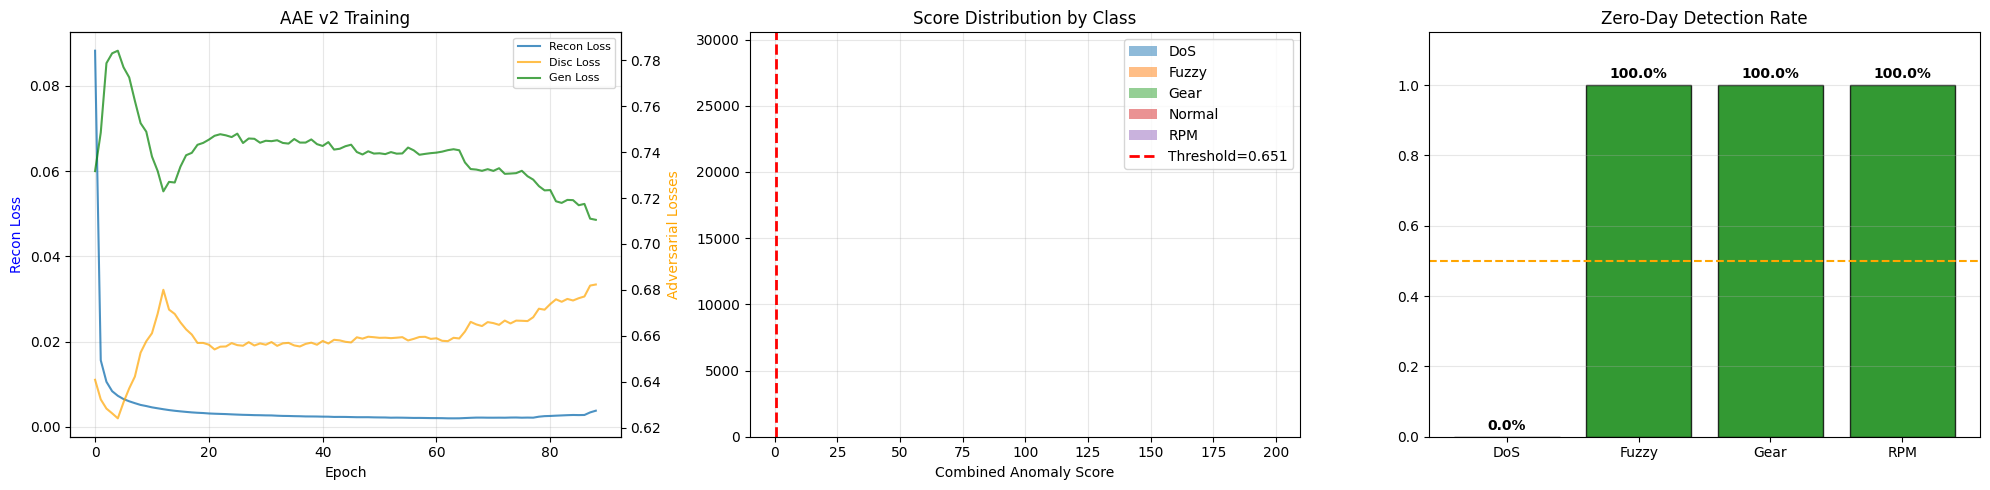

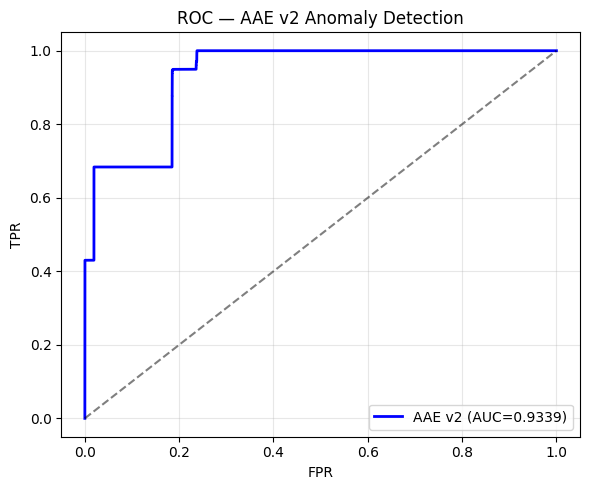

In [15]:
# === AAE Visualizations ===
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Training curves
axes[0].plot(ae_losses, label='Recon Loss', alpha=0.8)
ax0t = axes[0].twinx()
ax0t.plot(d_losses, label='Disc Loss', alpha=0.7, color='orange')
ax0t.plot(g_losses, label='Gen Loss', alpha=0.7, color='green')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Recon Loss', color='blue')
ax0t.set_ylabel('Adversarial Losses', color='orange')
axes[0].set_title('AAE v2 Training')
l1, lb1 = axes[0].get_legend_handles_labels()
l2, lb2 = ax0t.get_legend_handles_labels()
axes[0].legend(l1 + l2, lb1 + lb2, fontsize=8)
axes[0].grid(alpha=0.3)

# 2. Combined anomaly score distribution
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_test == cls_idx
    axes[1].hist(anomaly_scores[mask], bins=80, alpha=0.5, label=cls_name, density=True)
axes[1].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
axes[1].set_xlabel('Combined Anomaly Score')
axes[1].set_title('Score Distribution by Class')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Detection rate bars
names = [r['Attack'] for r in zd_results]
rates = [r['Detection Rate'] for r in zd_results]
colors = ['green' if r > 0.5 else 'red' for r in rates]
bars = axes[2].bar(names, rates, color=colors, edgecolor='black', alpha=0.8)
axes[2].axhline(y=0.5, color='orange', linestyle='--')
axes[2].set_ylim(0, 1.15)
axes[2].set_title('Zero-Day Detection Rate')
for bar, rate in zip(bars, rates):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{rate:.1%}', ha='center', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ROC curve
fpr_roc, tpr_roc, _ = roc_curve(is_anomaly_true, anomaly_scores)
roc_auc_val = auc(fpr_roc, tpr_roc)
plt.figure(figsize=(6, 5))
plt.plot(fpr_roc, tpr_roc, 'b-', lw=2, label=f'AAE v2 (AUC={roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC — AAE v2 Anomaly Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

AAE v2 SCORE DIAGNOSTICS


,Class,Count,Mean,Std,Min,Max,P50,P75,P90,P95,P97,P99
3,Normal,42779,0.2223,0.8851,0.0009,132.3091,0.1645,0.2696,0.3654,0.4838,0.6467,0.8677
0,DoS,2284,0.2837,0.0014,0.2797,0.2844,0.2844,0.2844,0.2844,0.2844,0.2844,0.2844
2,Gear,1831,0.6660,0.0002,0.6653,0.6666,0.6661,0.6661,0.6661,0.6661,0.6661,0.6661
4,RPM,1889,7.7295,0.0002,7.7288,7.7296,7.7296,7.7296,7.7296,7.7296,7.7296,7.7296
1,Fuzzy,1217,33.8520,23.1735,1.7168,199.8164,27.5850,42.3902,64.1523,78.4321,90.4589,112.6517


Threshold: 0.6507

Normal vs DoS percentile comparison
  P50: Normal=0.1645 | DoS=0.2844
  P75: Normal=0.2696 | DoS=0.2844
  P90: Normal=0.3654 | DoS=0.2844
  P95: Normal=0.4838 | DoS=0.2844
  P97: Normal=0.6467 | DoS=0.2844
  P99: Normal=0.8677 | DoS=0.2844
  DoS above threshold: 0/2284 (0.0%)


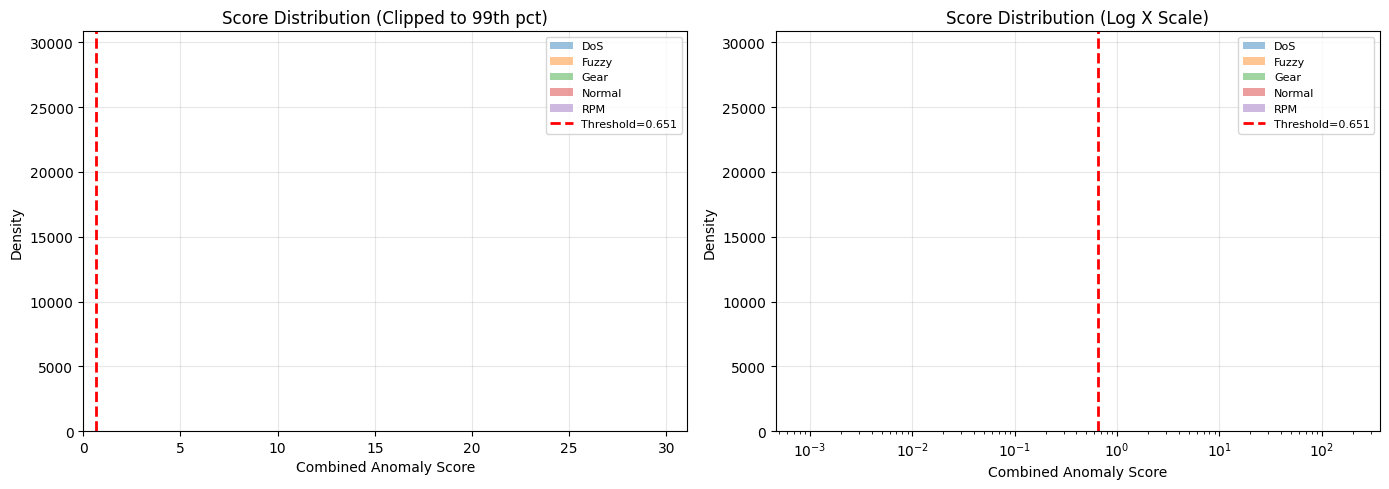

In [18]:
# === AAE Score Diagnostics ===
percentiles = [50, 75, 90, 95, 97, 99]
rows = []

for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_test == cls_idx
    cls_scores = anomaly_scores[mask]
    if cls_scores.size == 0:
        continue
    row = {
        'Class': cls_name,
        'Count': int(cls_scores.size),
        'Mean': float(np.mean(cls_scores)),
        'Std': float(np.std(cls_scores)),
        'Min': float(np.min(cls_scores)),
        'Max': float(np.max(cls_scores)),
    }
    for pct in percentiles:
        row[f'P{pct}'] = float(np.percentile(cls_scores, pct))
    rows.append(row)

score_diag_df = pd.DataFrame(rows).sort_values('Mean')
print('=' * 90)
print('AAE v2 SCORE DIAGNOSTICS')
print('=' * 90)
display(score_diag_df.round(4))
print(f'Threshold: {threshold:.4f}')

normal_scores = anomaly_scores[y_test == normal_label]
if 'DoS' in le.classes_:
    dos_idx = le.transform(['DoS'])[0]
    dos_scores = anomaly_scores[y_test == dos_idx]
    print('\nNormal vs DoS percentile comparison')
    for pct in [50, 75, 90, 95, 97, 99]:
        normal_pct = np.percentile(normal_scores, pct)
        dos_pct = np.percentile(dos_scores, pct)
        print(f'  P{pct:>2}: Normal={normal_pct:.4f} | DoS={dos_pct:.4f}')
    print(f"  DoS above threshold: {(dos_scores > threshold).sum()}/{dos_scores.size} ({((dos_scores > threshold).mean() if dos_scores.size else 0):.1%})")

clip_max = np.percentile(anomaly_scores, 99)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_test == cls_idx
    axes[0].hist(anomaly_scores[mask], bins=60, alpha=0.45, label=cls_name, density=True)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
axes[0].set_xlim(0, clip_max)
axes[0].set_title('Score Distribution (Clipped to 99th pct)')
axes[0].set_xlabel('Combined Anomaly Score')
axes[0].set_ylabel('Density')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_test == cls_idx
    cls_scores = np.clip(anomaly_scores[mask], 1e-6, None)
    axes[1].hist(cls_scores, bins=60, alpha=0.45, label=cls_name, density=True)
axes[1].axvline(max(threshold, 1e-6), color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
axes[1].set_xscale('log')
axes[1].set_title('Score Distribution (Log X Scale)')
axes[1].set_xlabel('Combined Anomaly Score')
axes[1].set_ylabel('Density')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Hybrid Decision System

In [16]:
# === Hybrid: CANForge + AAE v2 ===
canforge_pred_labels = le.inverse_transform(y_pred)
aae_anomaly = anomaly_scores > threshold
true_labels = le.inverse_transform(y_test)

hybrid_decisions = []
for i in range(len(y_test)):
    if canforge_pred_labels[i] != 'Normal':
        hybrid_decisions.append(f'Known:{canforge_pred_labels[i]}')
    elif aae_anomaly[i]:
        hybrid_decisions.append('Zero-Day')
    else:
        hybrid_decisions.append('Normal')

hybrid_decisions = np.array(hybrid_decisions)

hybrid_is_attack = hybrid_decisions != 'Normal'
true_is_attack = true_labels != 'Normal'

hybrid_acc = accuracy_score(true_is_attack, hybrid_is_attack)
hybrid_p, hybrid_r, hybrid_f1, _ = precision_recall_fscore_support(true_is_attack, hybrid_is_attack, average='binary')

cf_is_attack = y_pred != normal_label
cf_acc = accuracy_score(true_is_attack, cf_is_attack)
cf_p, cf_r, cf_f1, _ = precision_recall_fscore_support(true_is_attack, cf_is_attack, average='binary')

canforge_missed = (y_pred == normal_label) & true_is_attack
aae_caught = canforge_missed & aae_anomaly

print('=' * 70)
print('HYBRID SYSTEM — CANForge + AAE v2 (PyTorch GPU)')
print('=' * 70)
print(f'\n  {"Metric":<15} {"CANForge Only":>15} {"Hybrid (+ AAE)":>15}')
print(f'  {"-"*45}')
print(f'  {"Accuracy":<15} {cf_acc:>15.4f} {hybrid_acc:>15.4f}')
print(f'  {"Precision":<15} {cf_p:>15.4f} {hybrid_p:>15.4f}')
print(f'  {"Recall":<15} {cf_r:>15.4f} {hybrid_r:>15.4f}')
print(f'  {"F1-Score":<15} {cf_f1:>15.4f} {hybrid_f1:>15.4f}')
print(f'\n  CANForge missed: {canforge_missed.sum()}')
print(f'  AAE recovered:   {aae_caught.sum()}')
print(f'\n  Decision breakdown:')
for d in np.unique(hybrid_decisions):
    print(f'    {d:<20} {(hybrid_decisions == d).sum():>6}')

HYBRID SYSTEM — CANForge + AAE v2 (PyTorch GPU)

  Metric            CANForge Only  Hybrid (+ AAE)
  ---------------------------------------------
  Accuracy                 0.9957          0.9720
  Precision                0.9713          0.8376
  Recall                   0.9997          1.0000
  F1-Score                 0.9853          0.9116

  CANForge missed: 2
  AAE recovered:   2

  Decision breakdown:
    Known:DoS              2284
    Known:Fuzzy            1425
    Known:Gear             1834
    Known:RPM              1889
    Normal                41379
    Zero-Day               1189


# Final Report

In [17]:
import datetime

print('\n' + '='*70)
print('  CANForge — PyTorch GPU Final Report')
print(f'  Generated: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('='*70)

print(f'\n  Hardware:')
print(f'    GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'    VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB' if torch.cuda.is_available() else '')
print(f'    Framework: PyTorch {torch.__version__}')

print(f'\n  Dataset: {len(full_df):,} total samples, {N_FEATURES} features')
print(f'  Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

print(f'\n  CANForge Classifier:')
print(f'    Accuracy:  {accuracy:.4f}')
print(f'    Precision: {precision:.4f}')
print(f'    Recall:    {recall:.4f}')
print(f'    F1-Score:  {f1:.4f}')
print(f'    Training:  {train_time:.1f}s on GPU')
print(f'    Params:    {total_params:,}')

print(f'\n  AAE Zero-Day:')
print(f'    AUC-ROC:   {ano_auc:.4f}')
for r in zd_results:
    print(f'    {r["Attack"]:<10} {r["Detection Rate"]:.1%}')
print(f'    Training:  {aae_time:.1f}s on GPU')

print(f'\n  Hybrid System:')
print(f'    Accuracy:  {hybrid_acc:.4f}')
print(f'    F1-Score:  {hybrid_f1:.4f}')
print(f'    Zero-Day capable: Yes')

if torch.cuda.is_available():
    print(f'\n  GPU Memory Used: {torch.cuda.max_memory_allocated()/1024**2:.0f}MB / '
          f'{torch.cuda.get_device_properties(0).total_memory/1024**2:.0f}MB')

print('\n' + '='*70)


  CANForge — PyTorch GPU Final Report
  Generated: 2026-05-02 09:45:47

  Hardware:
    GPU: NVIDIA RTX A500 Laptop GPU
    VRAM: 4.0 GB
    Framework: PyTorch 2.11.0+cu128

  Dataset: 250,000 total samples, 16 features
  Train: 200,000 | Test: 50,000

  CANForge Classifier:
    Accuracy:  0.9957
    Precision: 0.9963
    Recall:    0.9957
    F1-Score:  0.9959
    Training:  451.7s on GPU
    Params:    241,373

  AAE Zero-Day:
    AUC-ROC:   0.9339
    DoS        0.0%
    Fuzzy      100.0%
    Gear       100.0%
    RPM        100.0%
    Training:  600.7s on GPU

  Hybrid System:
    Accuracy:  0.9720
    F1-Score:  0.9116
    Zero-Day capable: Yes

  GPU Memory Used: 132MB / 4096MB

